# Porovnanie modelov (ARIMAX, XGBOOST, ELASTIC NET)

In [1]:
#path config set
import sys
from pathlib import Path

project_root = Path.cwd().parent
for folder in ["functions", "other"]:
    p = str(project_root / folder)
    if p not in sys.path:
        sys.path.append(p)

In [2]:
# import potrebnych kniznic a konfiguracia notebooku
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

    #import importlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path


from functions_general import forecast_plot
from cred import MODEL_DATA_PATH
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

plt.rcParams.update({
    "figure.figsize": (13, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})


print("Importy uspesne.")


Importy uspesne.


In [16]:
model_data = Path(MODEL_DATA_PATH)

arimax_res_n = "arimax_res"
ARIMAX_RES_PATH = model_data / arimax_res_n

arimax_res = pd.read_parquet(
    ARIMAX_RES_PATH,
    engine="pyarrow"
)

xgb_res_n = "xgb_res"
XGB_RES_PATH = model_data / xgb_res_n

xgb_res = pd.read_parquet(
    XGB_RES_PATH,
    engine="pyarrow"
)

elnet_res_n = "elnet_res"
ELNET_RES_PATH = model_data / elnet_res_n

elnet_res = pd.read_parquet(
    ELNET_RES_PATH,
    engine="pyarrow"
)

In [17]:
model_data = Path(MODEL_DATA_PATH)

arimax_sum_n = "arimax_sum"
ARIMAX_SUM_PATH = model_data / arimax_sum_n

arimax_sum = pd.read_parquet(
    ARIMAX_SUM_PATH,
    engine="pyarrow"
)

xgb_sum_n = "xgb_sum"
XGB_SUM_PATH = model_data / xgb_sum_n

xgb_sum = pd.read_parquet(
    XGB_SUM_PATH,
    engine="pyarrow"
)

elnet_sum_n = "elnet_sum"
ELNET_SUM_PATH = model_data / elnet_sum_n

elnet_sum = pd.read_parquet(
    ELNET_SUM_PATH,
    engine="pyarrow"
)

In [18]:
summary_models = pd.concat([arimax_sum, xgb_sum, elnet_sum], ignore_index= True)

summary_models.index = ["ARIMAX", "XGBOOST", "ELASTIC NET"]

summary_models

,rmse_diff,rmse_level,wmape_level,me_level,n_obs,n_refits
ARIMAX,2.598397,2.598397,2.131229,-0.686766,24,24
XGBOOST,2.458848,2.458848,1.909815,-0.475379,24,24
ELASTIC NET,2.088754,2.088754,1.497372,-0.038750,24,24


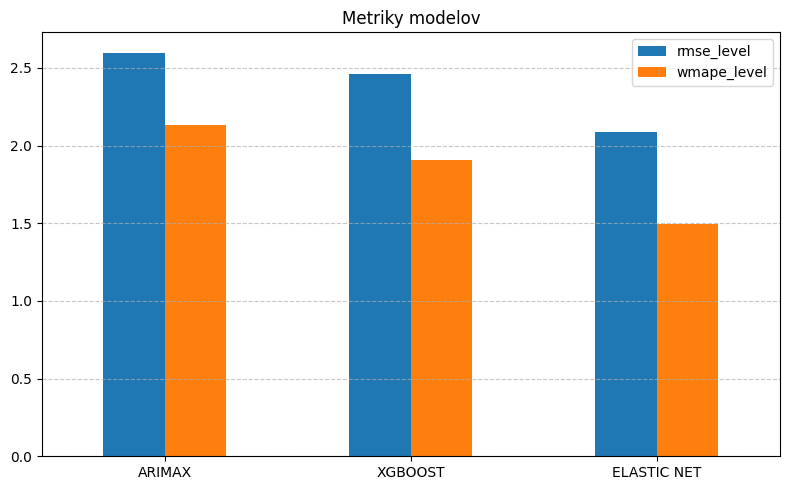

In [19]:
ax = summary_models[['rmse_level', 'wmape_level']].plot(kind='bar', figsize=(8, 5))

plt.title('Metriky modelov')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

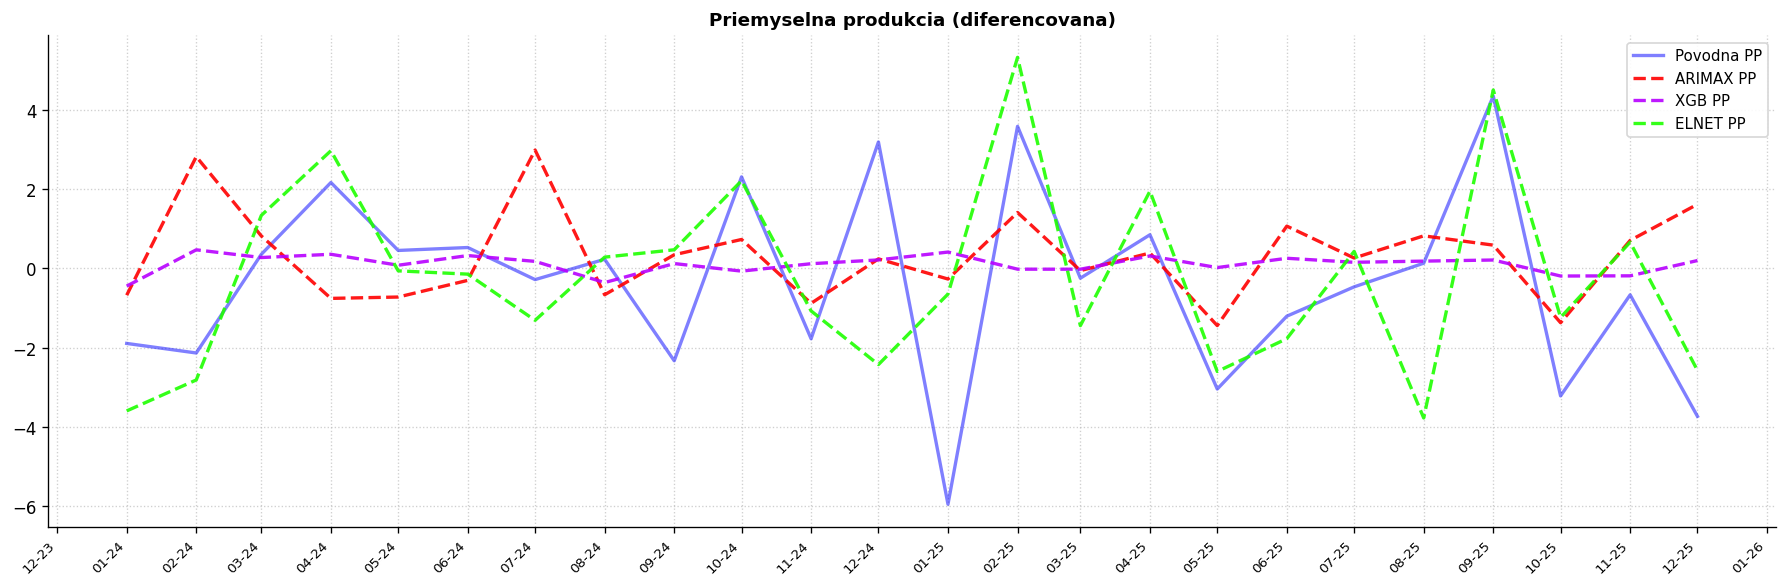

In [20]:
Y_axis = [arimax_res["actual_diff"], arimax_res["predicted_diff"], xgb_res["predicted_diff"], elnet_res["predicted_diff"]]
X_axis = [arimax_res.index] * len(Y_axis)
labels = ["Povodna PP", "ARIMAX PP", "XGB PP", "ELNET PP"] * len(Y_axis)
titles = ["Priemyselna produkcia (diferencovana)"]
colors = ["#0000FF", "#FF0000", "#B700FF", "#1EFF00"] * len(Y_axis)
linestyles = ["-","--", "--", "--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.5, 0.9, 0.9, 0.9] * len(Y_axis)
fig_size = [15,5]
num_rows = 1
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, 4)

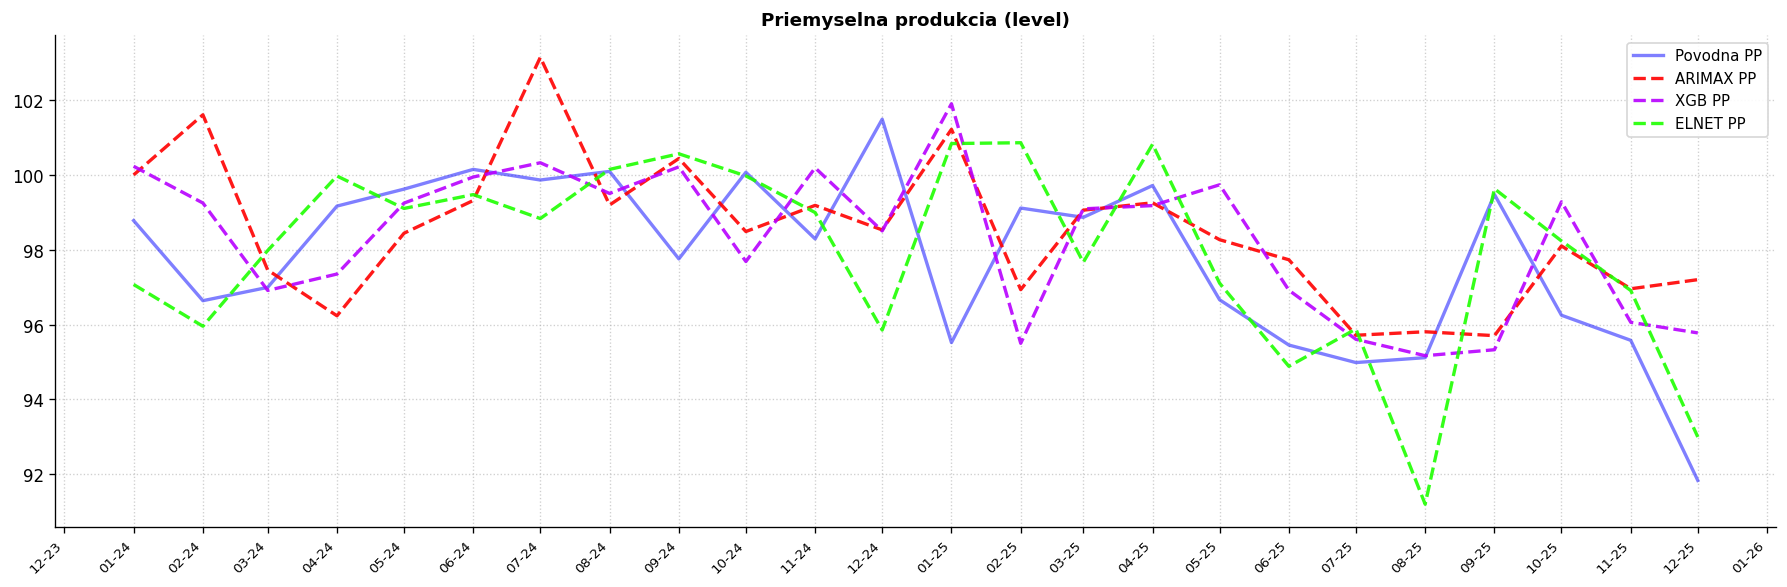

In [21]:
Y_axis = [arimax_res["actual_level"], arimax_res["predicted_level"], xgb_res["predicted_level"], elnet_res["predicted_level"]]
X_axis = [arimax_res.index] * len(Y_axis)
labels = ["Povodna PP", "ARIMAX PP", "XGB PP", "ELNET PP"] * len(Y_axis)
titles = ["Priemyselna produkcia (level)"]
colors = ["#0000FF", "#FF0000", "#B700FF", "#1EFF00"] * len(Y_axis)
linestyles = ["-","--", "--", "--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.5, 0.9, 0.9, 0.9] * len(Y_axis)
fig_size = [15,5]
num_rows = 1
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, 4)

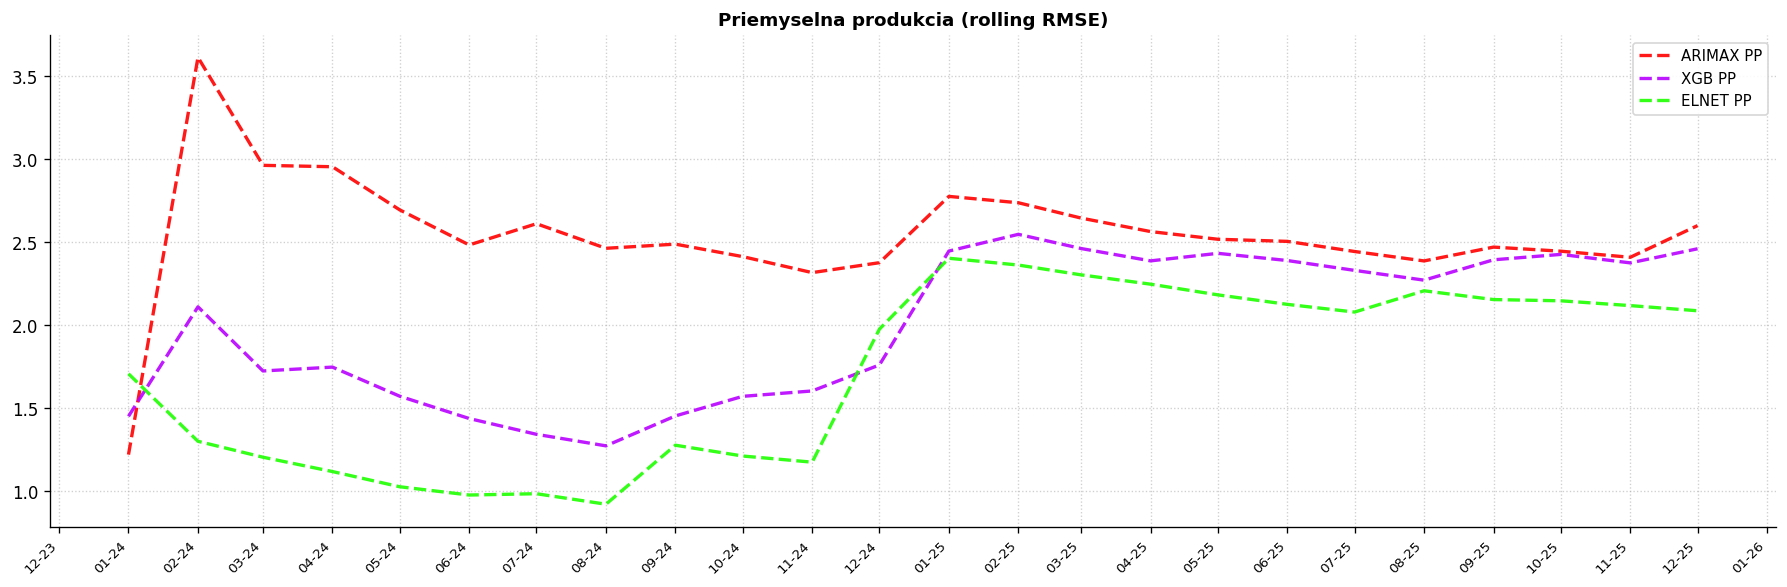

In [22]:
Y_axis = [arimax_res["rolling_rmse_level"], xgb_res["rolling_rmse_level"], elnet_res["rolling_rmse_level"]]
X_axis = [arimax_res.index] * len(Y_axis)
labels = ["ARIMAX PP", "XGB PP", "ELNET PP"] * len(Y_axis)
titles = ["Priemyselna produkcia (rolling RMSE)"]
colors = ["#FF0000", "#B700FF", "#1EFF00"] * len(Y_axis)
linestyles = ["--", "--", "--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.9, 0.9, 0.9] * len(Y_axis)
fig_size = [15,5]
num_rows = 1
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, 4)

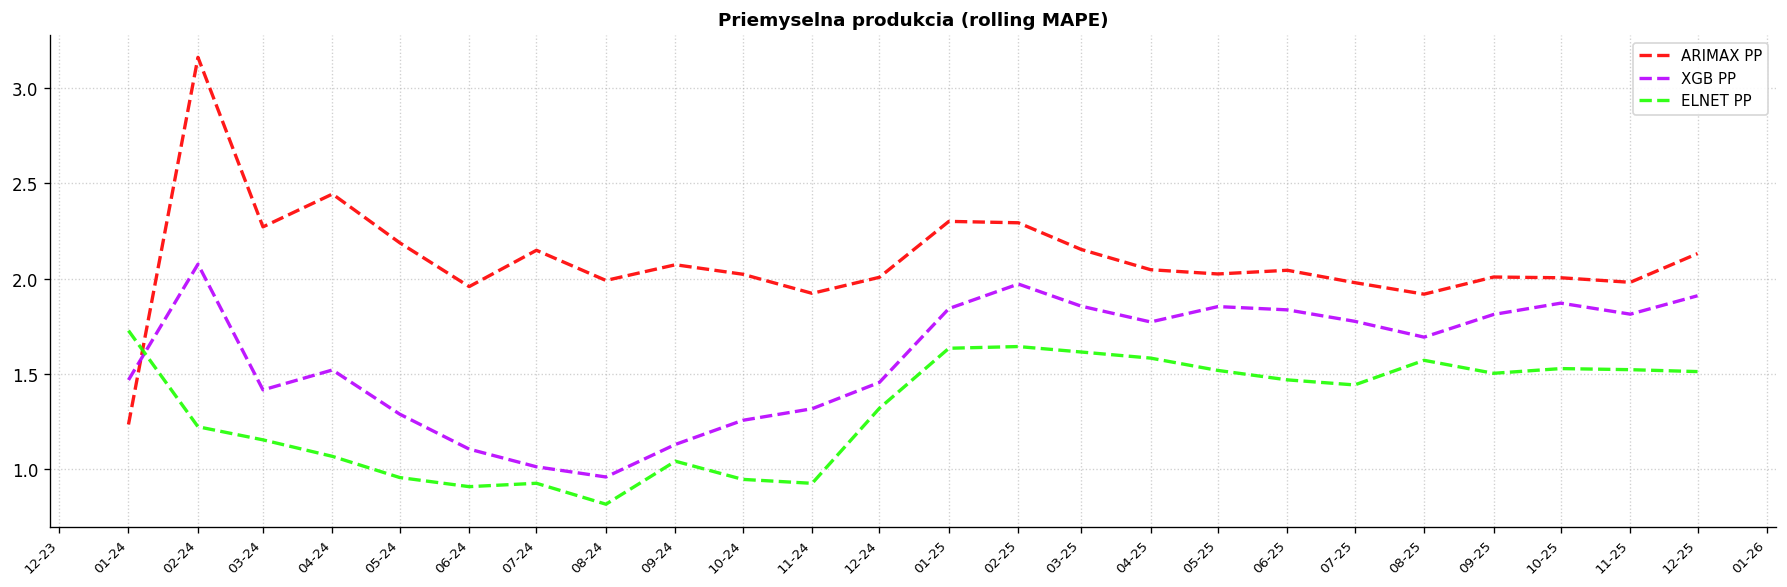

In [23]:
Y_axis = [arimax_res["rolling_mape_level"], xgb_res["rolling_mape_level"], elnet_res["rolling_mape_level"]]
X_axis = [arimax_res.index] * len(Y_axis)
labels = ["ARIMAX PP", "XGB PP", "ELNET PP"] * len(Y_axis)
titles = ["Priemyselna produkcia (rolling MAPE)"]
colors = ["#FF0000", "#B700FF", "#1EFF00"] * len(Y_axis)
linestyles = ["--", "--", "--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.9, 0.9, 0.9] * len(Y_axis)
fig_size = [15,5]
num_rows = 1
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, 4)

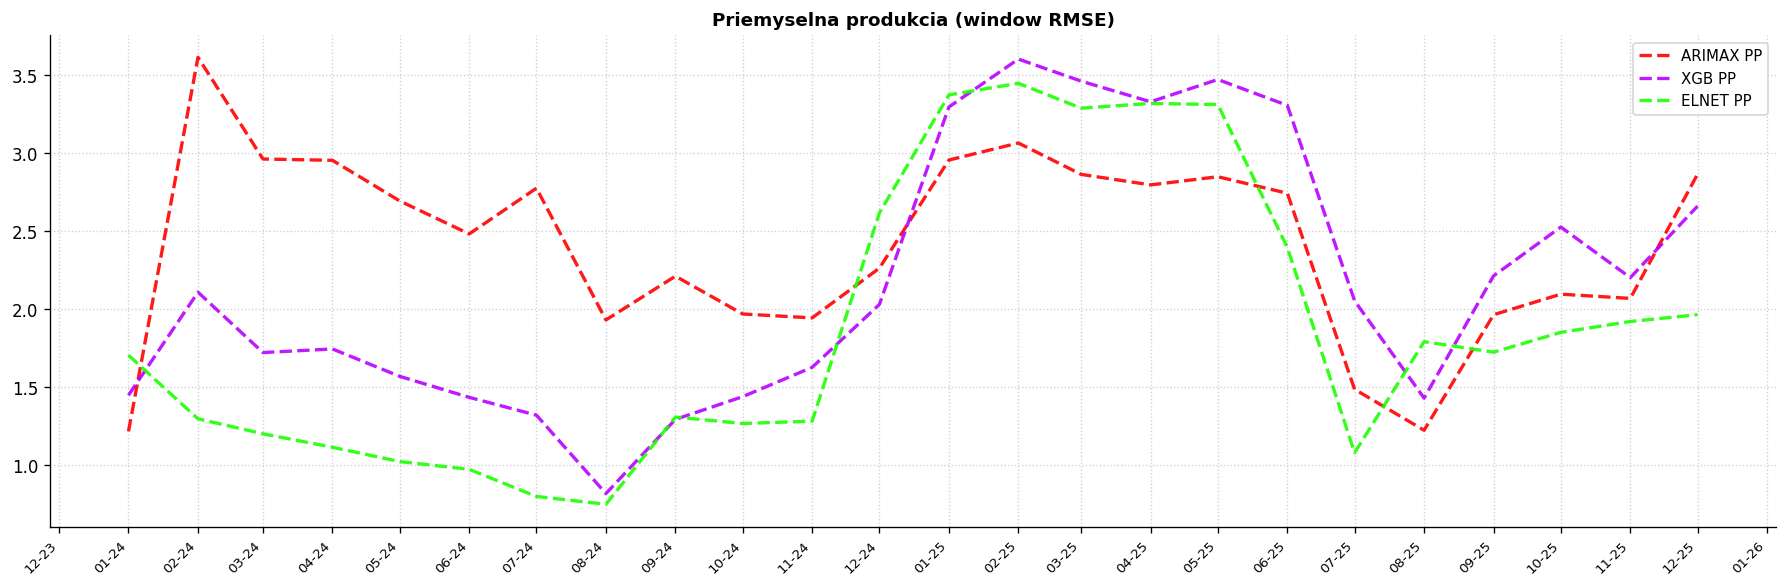

In [24]:
Y_axis = [arimax_res["window6_rmse_level"], xgb_res["window6_rmse_level"], elnet_res["window6_rmse_level"]]
X_axis = [arimax_res.index] * len(Y_axis)
labels = ["ARIMAX PP", "XGB PP", "ELNET PP"] * len(Y_axis)
titles = ["Priemyselna produkcia (window RMSE)"]
colors = ["#FF0000", "#B700FF", "#1EFF00"] * len(Y_axis)
linestyles = ["--", "--", "--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.9, 0.9, 0.9] * len(Y_axis)
fig_size = [15,5]
num_rows = 1
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, 4)

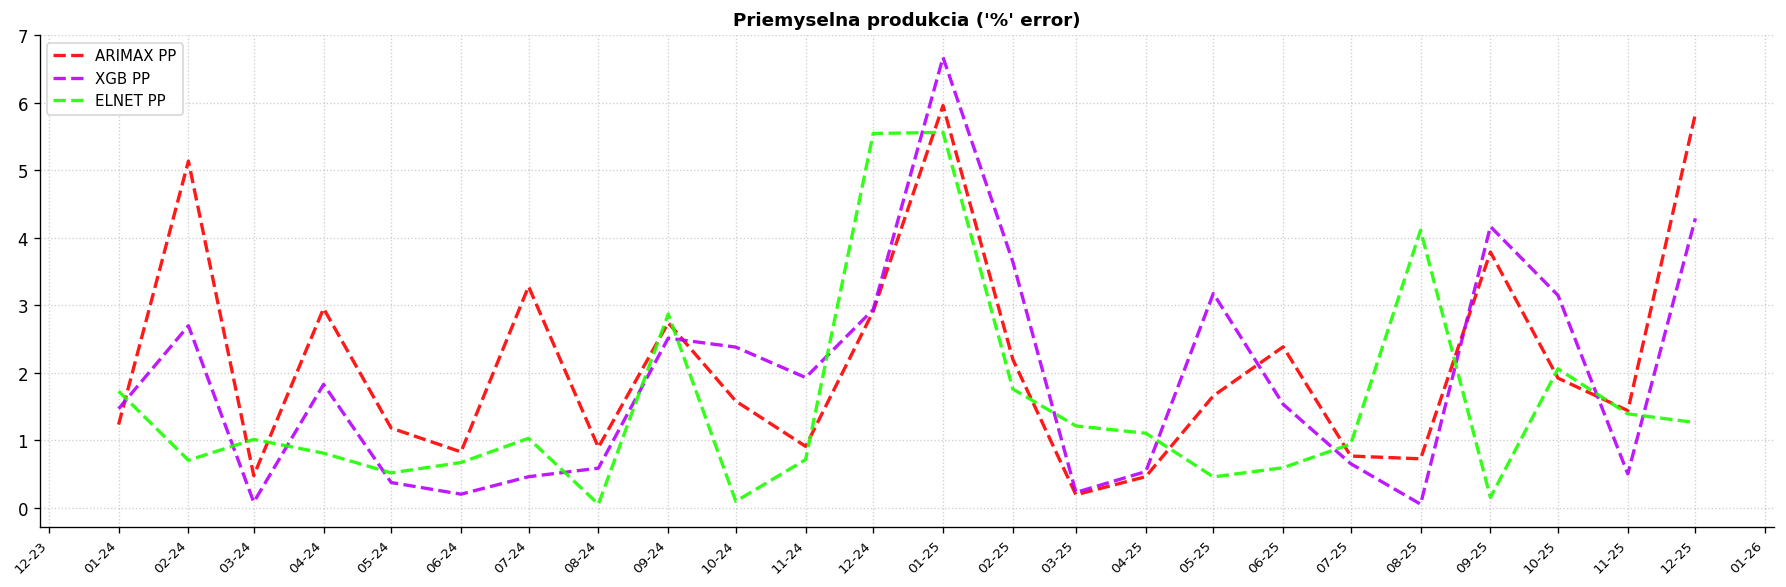

In [25]:
Y_axis = [arimax_res["pct_error_level"], xgb_res["pct_error_level"], elnet_res["pct_error_level"]]
X_axis = [arimax_res.index] * len(Y_axis)
labels = ["ARIMAX PP", "XGB PP", "ELNET PP"] * len(Y_axis)
titles = ["Priemyselna produkcia ('%' error)"]
colors = ["#FF0000", "#B700FF", "#1EFF00"] * len(Y_axis)
linestyles = ["--", "--", "--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.9, 0.9, 0.9] * len(Y_axis)
fig_size = [15,5]
num_rows = 1
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, 4)

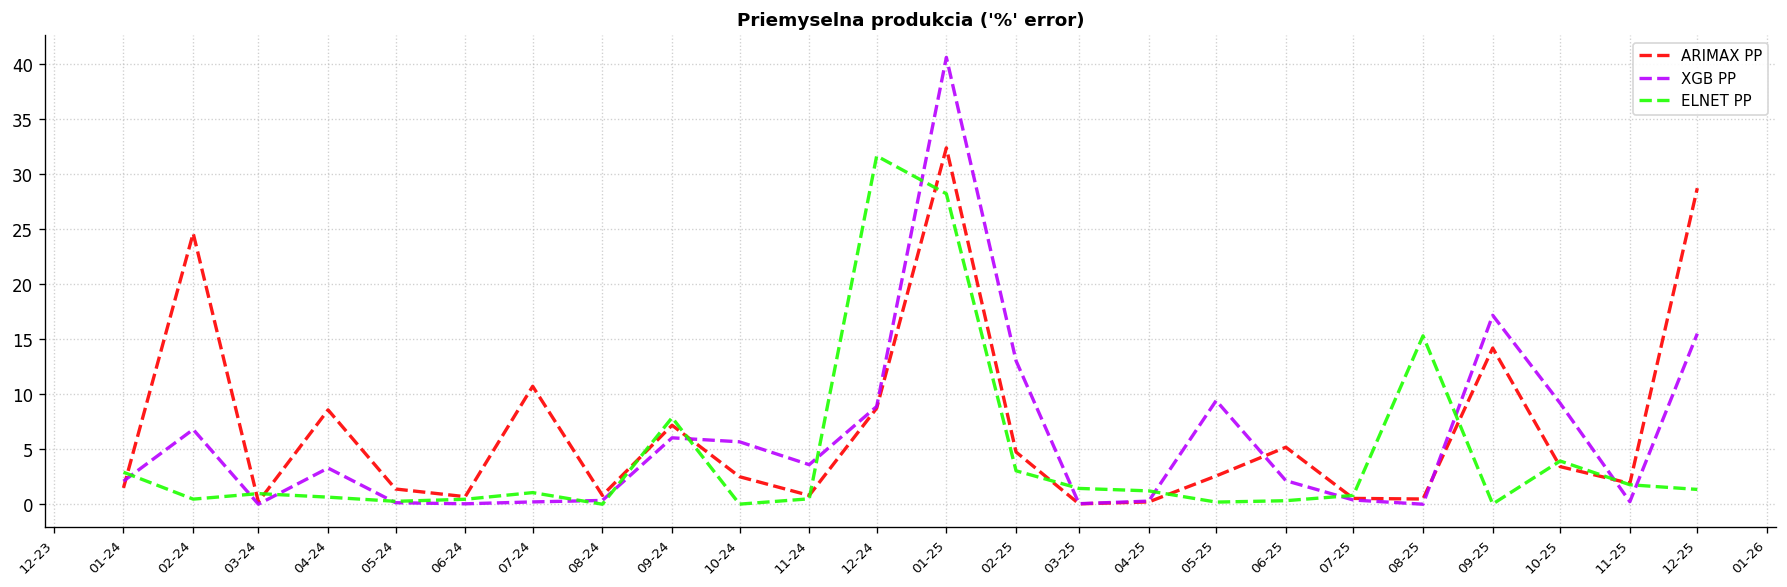

In [26]:
Y_axis = [arimax_res["sq_error_level"], xgb_res["sq_error_level"], elnet_res["sq_error_level"]]
X_axis = [arimax_res.index] * len(Y_axis)
labels = ["ARIMAX PP", "XGB PP", "ELNET PP"] * len(Y_axis)
titles = ["Priemyselna produkcia ('%' error)"]
colors = ["#FF0000", "#B700FF", "#1EFF00"] * len(Y_axis)
linestyles = ["--", "--", "--"] * len(Y_axis)
linewidths = [] * len(Y_axis)
alphas = [0.9, 0.9, 0.9] * len(Y_axis)
fig_size = [15,5]
num_rows = 1
num_cols = 1

_ = forecast_plot(X_axis,Y_axis,titles, labels, colors, linestyles, linewidths, alphas,fig_size, num_rows, num_cols, 4)